In [2]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# 폰트 설치
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
    -O fonts/NanumGothic.ttf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 등록
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 공통 데이터 생성 (시드 고정)
rng = np.random.default_rng(13)
N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre, '어절수': words,
    '음절수': syllables, '읽기시간': read_time, '난이도': difficulty,
})

trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

Q1 (0.5점) — matplotlib 기본 그래프 세 가지

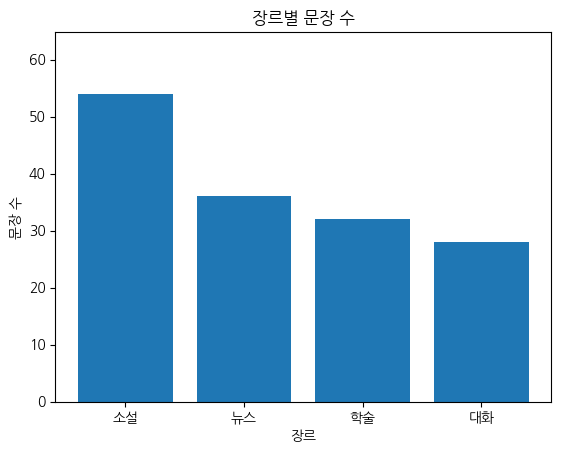

In [4]:
def plot_genre_bar(texts: pd.DataFrame) -> None:
    counts = texts['장르'].value_counts()
    fig, ax = plt.subplots()
    ax.bar(counts.index, counts.values)
    ax.set_title('장르별 문장 수')
    ax.set_xlabel('장르')
    ax.set_ylabel('문장 수')
    ax.set_ylim(0, counts.values.max() * 1.2)
    plt.show()

plot_genre_bar(texts)

value_counts()는 각 장르가 몇 번 등장하는지 세줍니다. ax.bar(x, y)에서 x는 막대 이름(장르), y는 막대 높이(문장 수)입니다. set_ylim(0, ...)으로 y축을 반드시 0부터 시작해야 막대 높이가 왜곡 없이 비율을 표현합니다.

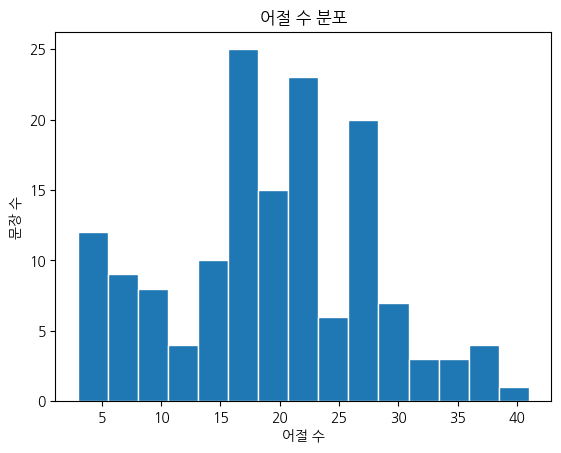

In [5]:
def plot_words_hist(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    ax.hist(texts['어절수'], bins=15, edgecolor='white')
    ax.set_title('어절 수 분포')
    ax.set_xlabel('어절 수')
    ax.set_ylabel('문장 수')
    plt.show()

plot_words_hist(texts)

ax.hist()는 숫자 변수를 구간(bin)으로 나눠 빈도를 셉니다. bins=15는 구간 개수를 15개로 지정하는 것이고, edgecolor='white'는 각 막대의 경계선을 흰색으로 그려 구분을 명확하게 합니다.
관찰: 어절 수는 주로 10~30 구간에 몰려 있으며, 학술(기본 28개)·뉴스(기본 22개) 장르가 많아 20 내외에서 가장 높은 빈도를 보인다.

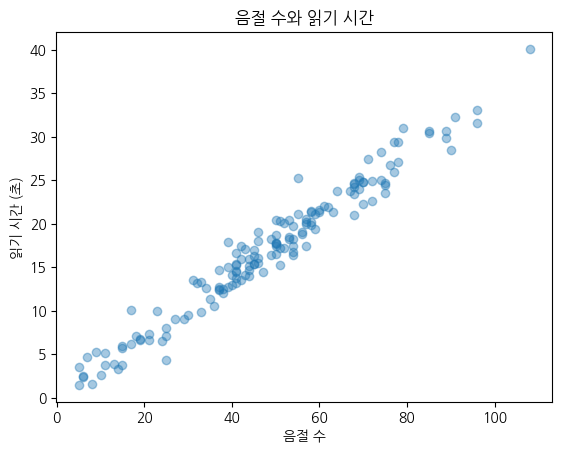

In [6]:
def plot_syllable_scatter(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)
    ax.set_title('음절 수와 읽기 시간')
    ax.set_xlabel('음절 수')
    ax.set_ylabel('읽기 시간 (초)')
    plt.show()

plot_syllable_scatter(texts)

ax.scatter(x, y)로 두 숫자 변수의 관계를 점으로 표현합니다. alpha=0.4는 점의 투명도를 40%로 설정해서, 점이 겹치더라도 밀도가 진하게 표시되어 데이터가 어디에 몰려있는지 파악할 수 있습니다.
관찰: 음절 수가 많을수록 읽기 시간도 늘어나는 강한 우상향 관계가 보인다. 이는 읽기시간이 음절수에 비례하도록 데이터를 생성했기 때문이다.

Q2 (0.5점) — 선 그래프와 서브플롯

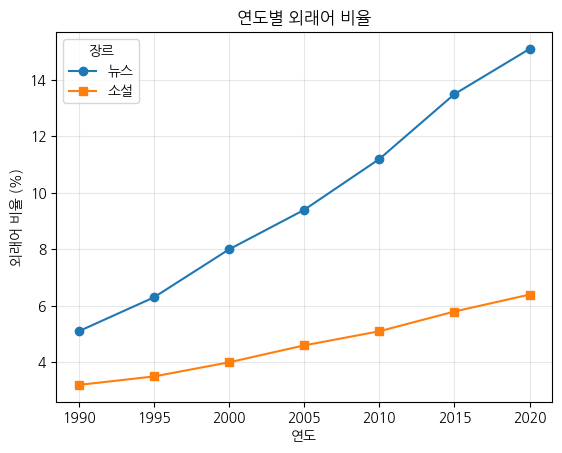

In [7]:
def plot_trends(trends: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
    ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
    ax.set_title('연도별 외래어 비율')
    ax.set_xlabel('연도')
    ax.set_ylabel('외래어 비율 (%)')
    ax.legend(title='장르')
    ax.grid(True, alpha=0.3)
    plt.show()

plot_trends(trends)

같은 ax에 ax.plot()을 두 번 호출하면 두 선이 하나의 그래프에 그려집니다. marker='o'는 원형, marker='s'는 사각형 마커입니다. label을 지정하고 ax.legend()를 호출해야 범례가 나타납니다. ax.grid(True, alpha=0.3)은 격자선을 30% 투명도로 표시합니다.
관찰: 두 장르 모두 외래어 비율이 꾸준히 증가하지만, 뉴스는 30년간 약 3배 증가한 반면 소설은 2배 수준으로 뉴스의 외래어 유입 속도가 훨씬 가파르다.

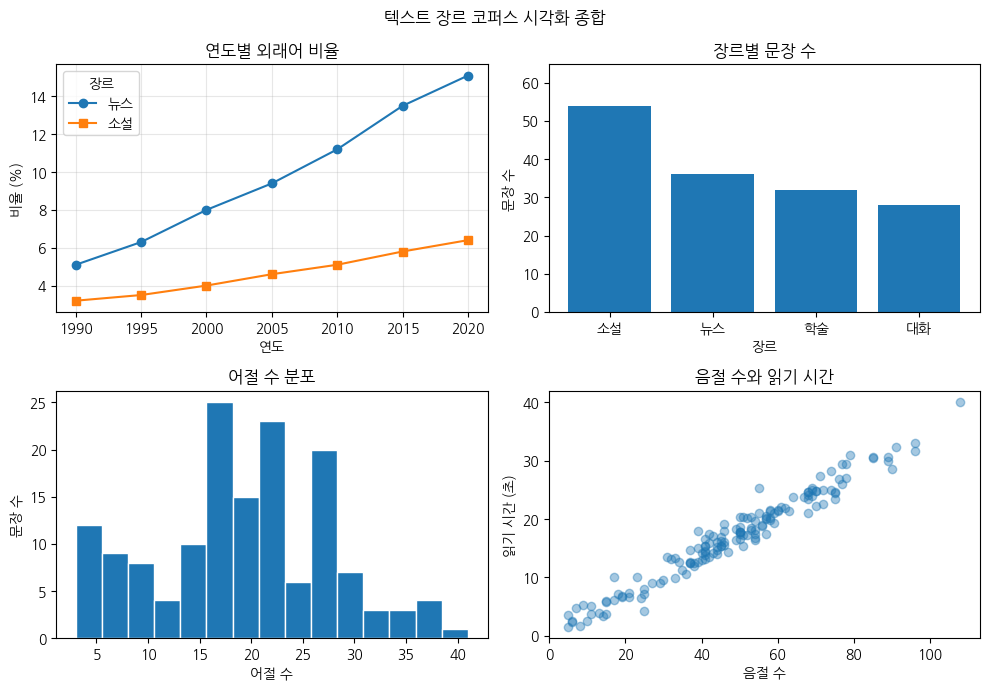

In [8]:
def plot_subplots(texts: pd.DataFrame, trends: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    # [0,0] 선 그래프 (Q2a)
    axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
    axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
    axes[0, 0].set_title('연도별 외래어 비율')
    axes[0, 0].set_xlabel('연도')
    axes[0, 0].set_ylabel('비율 (%)')
    axes[0, 0].legend(title='장르')
    axes[0, 0].grid(True, alpha=0.3)

    # [0,1] 막대 그래프 (Q1a)
    counts = texts['장르'].value_counts()
    axes[0, 1].bar(counts.index, counts.values)
    axes[0, 1].set_title('장르별 문장 수')
    axes[0, 1].set_xlabel('장르')
    axes[0, 1].set_ylabel('문장 수')
    axes[0, 1].set_ylim(0, counts.values.max() * 1.2)

    # [1,0] 히스토그램 (Q1b)
    axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white')
    axes[1, 0].set_title('어절 수 분포')
    axes[1, 0].set_xlabel('어절 수')
    axes[1, 0].set_ylabel('문장 수')

    # [1,1] 산점도 (Q1c)
    axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)
    axes[1, 1].set_title('음절 수와 읽기 시간')
    axes[1, 1].set_xlabel('음절 수')
    axes[1, 1].set_ylabel('읽기 시간 (초)')

    fig.suptitle('텍스트 장르 코퍼스 시각화 종합')
    fig.tight_layout()
    fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')  # show() 전에!
    plt.show()

plot_subplots(texts, trends)

plt.subplots(2, 2)는 2행 2열 총 4개의 Axes를 만들고 axes[행, 열]로 접근합니다. figsize=(10, 7)은 그림 크기를 인치 단위로 지정합니다. fig.suptitle()은 전체 그림의 제목, fig.tight_layout()은 서브플롯 간 겹침을 자동으로 방지합니다. savefig는 반드시 plt.show() 이전에 호출해야 합니다. show() 이후에는 그림이 초기화되어 빈 파일이 저장됩니다.

Q3 (0.5점) — seaborn으로 그룹과 관계 보기

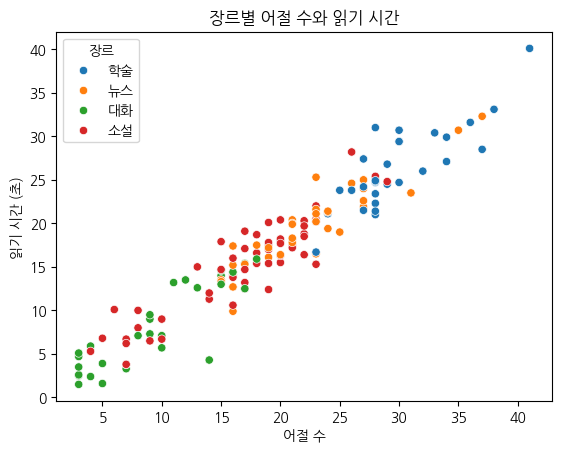

In [9]:
def plot_sns_scatter(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', ax=ax)
    ax.set_title('장르별 어절 수와 읽기 시간')
    ax.set_xlabel('어절 수')
    ax.set_ylabel('읽기 시간 (초)')
    plt.show()

plot_sns_scatter(texts)

seaborn의 scatterplot은 data=에 DataFrame을 통째로 넘기고 열 이름을 문자열로 지정합니다. hue='장르'만 추가하면 장르별로 색을 자동으로 나누고 범례까지 생성합니다. matplotlib으로 같은 효과를 내려면 장르를 일일이 필터링해서 scatter()를 여러 번 호출해야 합니다. ax=ax로 어느 Axes에 그릴지 명시해야 matplotlib과 함께 사용할 수 있습니다.

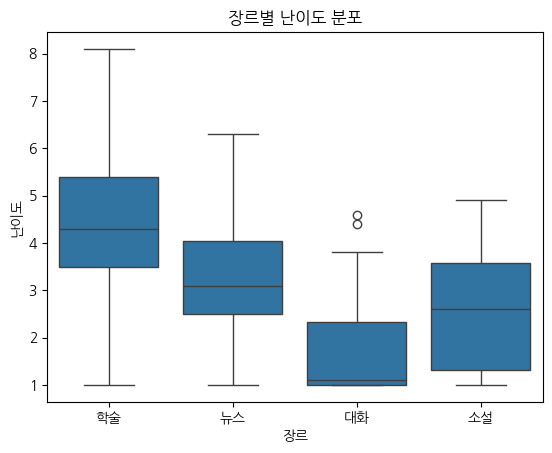

In [10]:
def plot_difficulty_box(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    sns.boxplot(data=texts, x='장르', y='난이도', ax=ax)
    ax.set_title('장르별 난이도 분포')
    ax.set_xlabel('장르')
    ax.set_ylabel('난이도')
    plt.show()

plot_difficulty_box(texts)

상자그림(boxplot)은 가운데 선이 중앙값, 상자가 중간 50% 구간(IQR), 수염이 전체 범위, 점이 이상치를 나타냅니다. 평균 하나만 보여주는 막대 그래프와 달리 데이터의 퍼짐과 분포 형태까지 확인할 수 있습니다.
관찰: 난이도 중앙값은 학술이 가장 높다(기본 어절수 28로 설정됨). 퍼짐(상자 크기)은 어절수 분산이 큰 뉴스 또는 소설에서 상대적으로 크게 나타난다.

In [ ]:
def plot_corr_heatmap(texts: pd.DataFrame) -> None:
    corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()
    fig, ax = plt.subplots()
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
    ax.set_title('변수 간 상관계수')
    plt.show()

plot_corr_heatmap(texts)

.corr()은 열 간의 상관계수 행렬을 계산합니다(-1~1). annot=True는 각 칸에 숫자를 표시하고, cmap='coolwarm'은 양의 상관은 빨강, 음의 상관은 파랑으로 표현합니다. vmin=-1, vmax=1로 색상 기준을 고정합니다.
관찰: 음절수와 읽기시간이 가장 강하게 함께 증가한다. 이는 데이터 생성 시 read_time = syllables * 0.35 + noise로 직접 비례하게 만들었기 때문이며, 실제로도 글자 수가 많을수록 읽는 데 더 많은 시간이 소요되는 자연스러운 관계를 반영한다.

Q4 (0.5점) — 정직한 그래프 (비판적으로 보기)

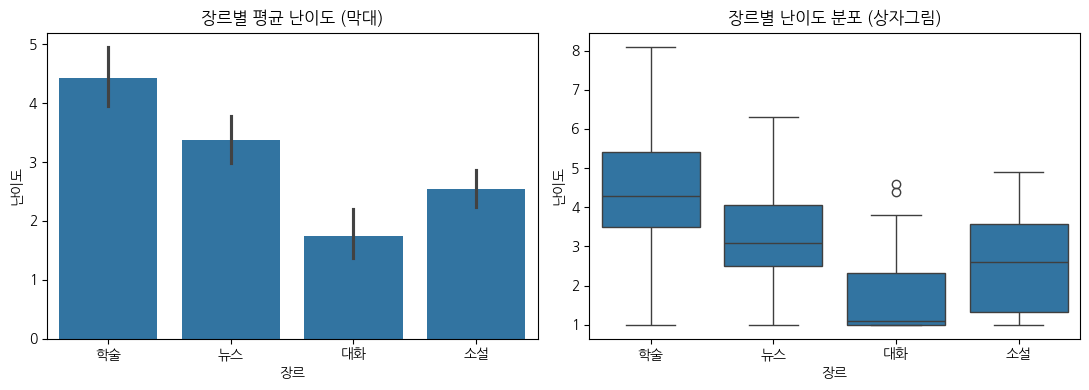

In [11]:
def plot_honest_comparison(texts: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
    axes[0].set_title('장르별 평균 난이도 (막대)')
    axes[0].set_xlabel('장르')
    axes[0].set_ylabel('난이도')

    sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
    axes[1].set_title('장르별 난이도 분포 (상자그림)')
    axes[1].set_xlabel('장르')
    axes[1].set_ylabel('난이도')

    fig.tight_layout()
    plt.show()

plot_honest_comparison(texts)

sns.barplot은 자동으로 평균을 계산하고 오차막대(95% 신뢰구간)를 그려줍니다. 이를 "다이너마이트 플롯"이라고도 부르는데, 평균 하나만 요약하여 분포 정보를 잃어버리는 문제가 있습니다.
서술: 왼쪽 막대 그래프는 장르별 평균값만 보여주어 각 장르 내 난이도가 얼마나 고르게 분포하는지, 이상치가 있는지를 전혀 알 수 없다. 예를 들어 뉴스와 소설의 평균 난이도가 비슷하더라도, 뉴스는 난이도가 넓게 퍼진 반면 소설은 특정 구간에 밀집된 분포일 수 있으며 이 차이는 막대로는 완전히 숨겨진다.

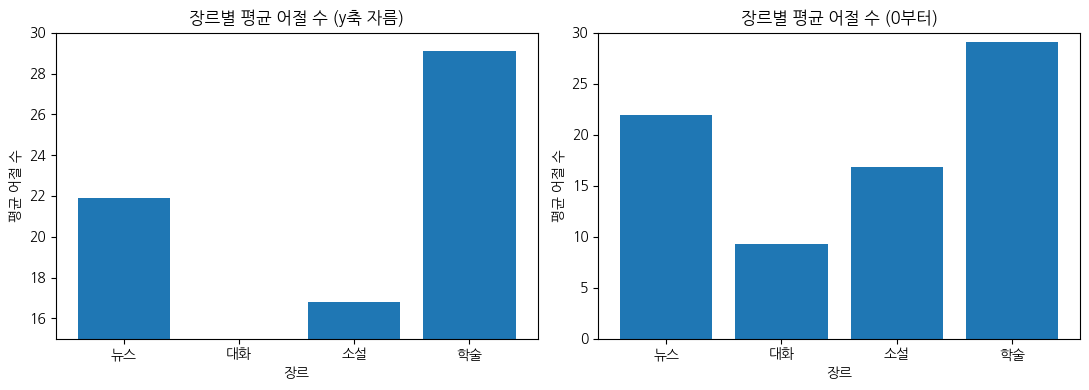

In [12]:
def plot_ylim_trap(texts: pd.DataFrame) -> None:
    mean_words = texts.groupby('장르')['어절수'].mean()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # 왼쪽: y축 자름 (함정)
    axes[0].bar(mean_words.index, mean_words.values)
    axes[0].set_ylim(15, 30)
    axes[0].set_title('장르별 평균 어절 수 (y축 자름)')
    axes[0].set_xlabel('장르')
    axes[0].set_ylabel('평균 어절 수')

    # 오른쪽: 0부터 (정직)
    axes[1].bar(mean_words.index, mean_words.values)
    axes[1].set_ylim(0, 30)
    axes[1].set_title('장르별 평균 어절 수 (0부터)')
    axes[1].set_xlabel('장르')
    axes[1].set_ylabel('평균 어절 수')

    fig.tight_layout()
    plt.show()

plot_ylim_trap(texts)

groupby('장르')['어절수'].mean()으로 장르별 평균 어절수를 구합니다. 같은 데이터를 y축 범위만 다르게 해서 두 개로 나란히 그립니다.
서술: y축을 15에서 시작하면 대화(약 9어절)와 학술(약 28어절)의 차이가 극적으로 커 보이지만, 0부터 그리면 실제 차이가 전체 값의 범위 안에서 얼마나 작은지 파악할 수 있다. 막대 그래프에서 y축을 0부터 그려야 하는 이유는 막대의 높이 자체가 크기의 비율을 표현하기 때문이며, 잘린 y축은 시각적 비율을 왜곡하여 독자를 오도하는 "거짓말하는 그래프"가 된다.

해당 과제는 claude.ai의 도움을 받아 작성됨

https://claude.ai/share/f862c355-55a3-4e1b-bf0c-25446f7378a1